In [1]:
!pip install category_encoders

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, MaxAbsScaler,
                                   RobustScaler, QuantileTransformer)
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

sns.set_theme(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 991.2 kB/s eta 0:00:00


**Carregamento e limpeza dos dados**

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/MillenaNeves/Ciencia-de-dados/main/acidentes_recife_2024%20(1).csv', sep=';', decimal=',')

# remoção de colunas 100% nulas identificadas na EDA
colunas_para_remover = ['situacao_placa', 'condicao_via', 'sinalizacao']
df = df.drop(columns=colunas_para_remover, errors='ignore')

# tratamento da variável alvo 'natureza'
# removendo categorias que não indicam gravidade
df = df[~df['natureza'].isin(['APOIO', 'ENTRADA E SAÍDA'])]

# filtragem apenas 2024
# converte para datetime e filtra as datas erradas
df['data'] = pd.to_datetime(df['data'], errors='coerce')
df = df[df['data'].dt.year == 2024]

# tratamento rápido de nulos para o KNN rodar sem erros
df = df.dropna(subset=['natureza'])

# imputando 0 nas quantidades de veículos/vítimas caso haja algum nulo
cols_numericas = ['auto', 'moto', 'ciclom', 'ciclista', 'pedestre', 'onibus', 'caminhao', 'vitimas']
df[cols_numericas] = df[cols_numericas].fillna(0)

print(f"Tamanho do dataset após limpeza: {df.shape}")

Tamanho do dataset após limpeza: (5279, 34)


**Divisão de treino e teste (definindo as features numéricas e categóricas que usaremos no modelo)**

In [3]:
# escolhi 'bairro' e 'tipo' como categóricas principais
features_cat = ['bairro', 'tipo']
features_num = ['auto', 'moto', 'ciclom', 'ciclista', 'pedestre', 'onibus', 'caminhao', 'vitimas']

# lidando com possíveis nulos nas features categóricas antes da divisão
df[features_cat] = df[features_cat].fillna('DESCONHECIDO')

# separando X (features) e y (target)
X = df[features_cat + features_num]
y = df['natureza']

# split 70/30 (stratify=y garante que a proporção de vítimas fatais se mantenha)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

Treino: (3695, 10) | Teste: (1584, 10)


**Pipeline de avaliação**

In [4]:
import warnings
warnings.filterwarnings('ignore')

# dicionário de encoders )
encoders = {
    'One-hot': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
    'Dummy': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
    'Effect': ce.SumEncoder()
}

# dicionário de scalers
scalers = {
    'Standard': StandardScaler(),
    'Min-Max': MinMaxScaler(),
    'MaxAbs': MaxAbsScaler(),
    'Robust': RobustScaler(),
    'Quantile (Uniforme)': QuantileTransformer(output_distribution='uniform', random_state=42),
    'Quantile (Normal)': QuantileTransformer(output_distribution='normal', random_state=42)
}

resultados = []

# loop de treinamento iterando sobre todas as combinações
for nome_enc, encoder in encoders.items():
    for nome_scale, scaler in scalers.items():
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', scaler, features_num),
                ('cat', encoder, features_cat)
            ],
            remainder='drop'
        )

        # montando o Pipeline final com o kNN (n_neighbors = 5 conforme Atividade)
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', KNeighborsClassifier(n_neighbors=5))
        ])

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)

        # average='macro' no F1-Score pq as classes são desbalanceadas
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')

        # salvar os resultados
        resultados.append({
            'Dataset': 'Acidentes Recife 2024',
            'Encoding': nome_enc,
            'Scaling': nome_scale,
            'Acurácia KNN': round(acc, 4),
            'F1-Score': round(f1, 4)
        })

df_resultados = pd.DataFrame(resultados)
display(df_resultados)

,Dataset,Encoding,Scaling,Acurácia KNN,F1-Score
0,Acidentes Recife 2024,One-hot,Standard,0.9931,0.7233
1,Acidentes Recife 2024,One-hot,Min-Max,0.9318,0.5407
2,Acidentes Recife 2024,One-hot,MaxAbs,0.9318,0.5407
3,Acidentes Recife 2024,One-hot,Robust,0.9741,0.6899
4,Acidentes Recife 2024,One-hot,Quantile (Uniforme),0.9331,0.5432
5,Acidentes Recife 2024,One-hot,Quantile (Normal),0.9905,0.7035
6,Acidentes Recife 2024,Dummy,Standard,0.9931,0.7233
7,Acidentes Recife 2024,Dummy,Min-Max,0.9280,0.5341
8,Acidentes Recife 2024,Dummy,MaxAbs,0.9280,0.5341
9,Acidentes Recife 2024,Dummy,Robust,0.9747,0.6909


**Visualização e Gráficos para o Relatório**

**Gráfico 1: Comparação de acurácia**

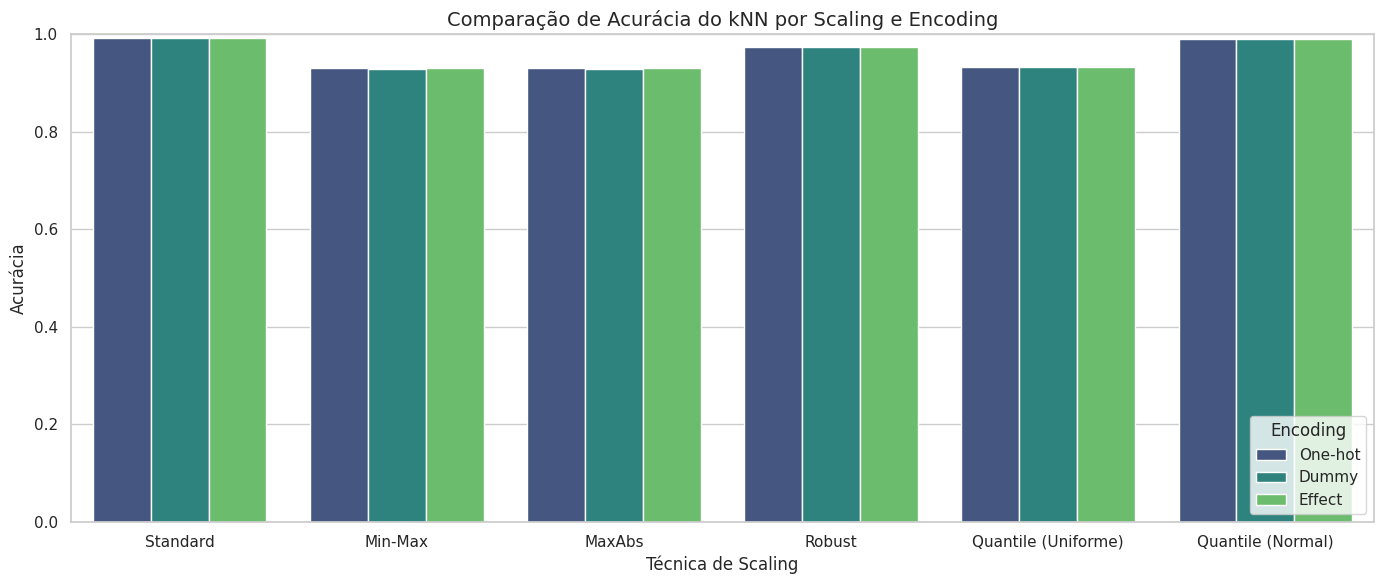

In [5]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_resultados, x='Scaling', y='Acurácia KNN', hue='Encoding', palette='viridis')
plt.title('Comparação de Acurácia do kNN por Scaling e Encoding', fontsize=14)
plt.ylabel('Acurácia', fontsize=12)
plt.xlabel('Técnica de Scaling', fontsize=12)
plt.ylim(0, 1.0) # trava o eixo Y entre 0 e 1 (100%)
plt.legend(title='Encoding', loc='lower right')
plt.tight_layout()
plt.show()

**Gráfico 2: Comparação de F1-Score (melhor p dados desbalanceados)**

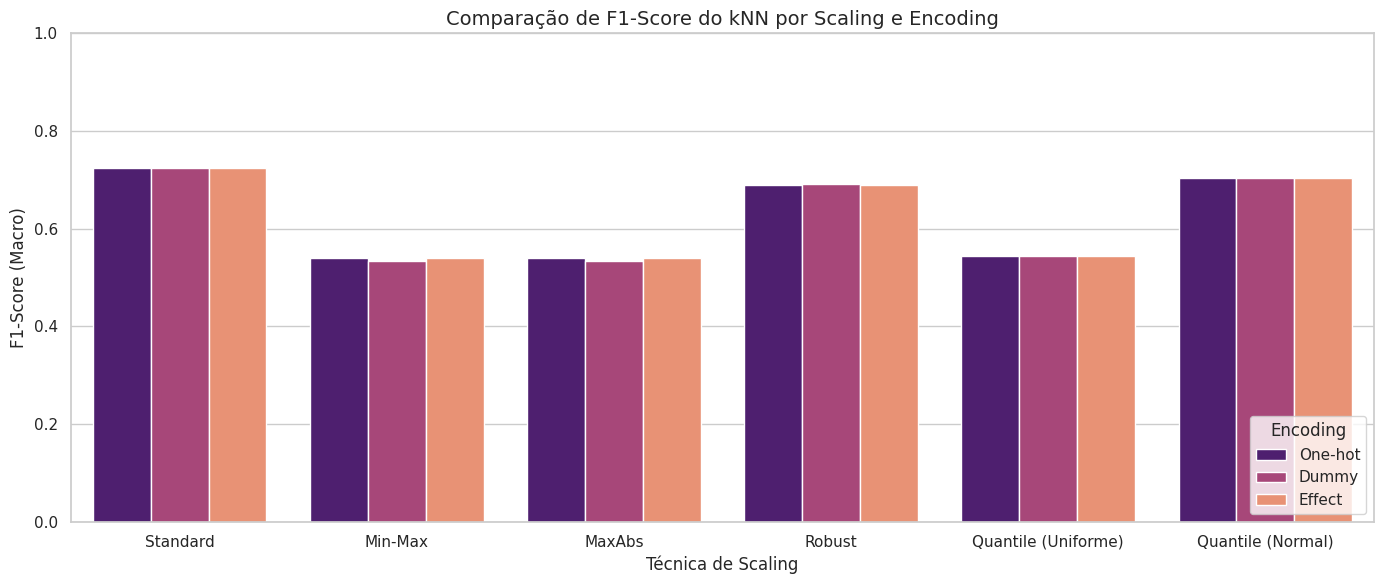

In [6]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_resultados, x='Scaling', y='F1-Score', hue='Encoding', palette='magma')
plt.title('Comparação de F1-Score do kNN por Scaling e Encoding', fontsize=14)
plt.ylabel('F1-Score (Macro)', fontsize=12)
plt.xlabel('Técnica de Scaling', fontsize=12)
plt.ylim(0, 1.0)
plt.legend(title='Encoding', loc='lower right')
plt.tight_layout()
plt.show()


In [7]:
print("\nTabela formatada para o relatório:")
tabela_relatorio = df_resultados[['Dataset', 'Encoding', 'Scaling', 'Acurácia KNN', 'F1-Score']]
display(tabela_relatorio.sort_values(by=['Acurácia KNN', 'F1-Score'], ascending=[False, False]))


Tabela formatada para o relatório:


,Dataset,Encoding,Scaling,Acurácia KNN,F1-Score
0,Acidentes Recife 2024,One-hot,Standard,0.9931,0.7233
6,Acidentes Recife 2024,Dummy,Standard,0.9931,0.7233
12,Acidentes Recife 2024,Effect,Standard,0.9931,0.7233
5,Acidentes Recife 2024,One-hot,Quantile (Normal),0.9905,0.7035
11,Acidentes Recife 2024,Dummy,Quantile (Normal),0.9905,0.7035
17,Acidentes Recife 2024,Effect,Quantile (Normal),0.9905,0.7035
9,Acidentes Recife 2024,Dummy,Robust,0.9747,0.6909
3,Acidentes Recife 2024,One-hot,Robust,0.9741,0.6899
15,Acidentes Recife 2024,Effect,Robust,0.9741,0.6899
4,Acidentes Recife 2024,One-hot,Quantile (Uniforme),0.9331,0.5432
